In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE
from umap import UMAP
from sklearn.preprocessing import StandardScaler

In [50]:
FILE = "Individual AnnotationsORC.xlsx"
 
df = pd.read_excel(FILE, header=[0, 1])

In [51]:
FILE = "Individual AnnotationsORC.xlsx"
 
df = pd.read_excel(FILE, header=[0, 1])
# Aplanar columnas
df.columns = [
    b if not str(b).startswith("Unnamed") else a
    for a, b in df.columns
]
 
# Primera columna = nombre del paper
df = df.rename(columns={df.columns[0]: "paper"})
df = df.dropna(subset=["paper"])
df = df[df["paper"].astype(str).str.match(r"^\d+\.")]
df["paper"] = df["paper"].astype(str).str.strip()
 
print(f"Papers: {len(df)}")


Papers: 44


In [61]:
df_cat

,¿Framework?,Método estándar,¿Cuál Framework?,Datos utilizados,Dimensiones,Ecuación
0,tensorflow (wavenet) y pytorch (conditional au...,ray tracing and fd,crewes and seismic_cpml,synthetic generated with seismic_cpml,2d,acustic
1,not reported in the article. however in the re...,fd,NR,"synthetic. specifically, the sigsbee2a model a...",2d,helmholtz
2,not reported.,fd,NR,"synthetic. a total of 20,000 random sets of mo...",2d,elastic
3,NR,fd,NR,synthetic wavefields within a wide frequency r...,2d,helmholtz
4,the regression models were trained in the matl...,ps,k-wave,"to generate the synthetic seismograms, we have...",3d,elastic
5,cudnn,fd,NR,NR,3d,acustic and elastic
6,keras,fd,mos and devito,mos and devito synthetic data were used to tra...,1d,acustic
7,pytorch,fd,NR,synthetic data using fd (not fully sure) and e...,1d,biot–squirt
8,NR,fd,NR,synthetic data using fd,2d,acoustic
9,NR,sem,sem3d,it is trained on the hemews-3d,3d,elastic


In [59]:
# ── 2. Seleccionar solo columnas categóricas ───────────────────────────────────
CAT_KEYWORDS = ["Dimensiones", "Ecuaci", "Framework", "Método", "Datos"]
cat_cols = [c for c in df.columns if any(k in c for k in CAT_KEYWORDS)]
print(f"Columnas categóricas: {cat_cols}")
 
# ── 3. Normalizar valores ──────────────────────────────────────────────────────
def clean(v):
    v = str(v).strip().lower()
    return "NR" if v in ["", "nan", "not reported", "not applicable",
                         "not explicitly stated", "not specified"] else v
 
df_cat = df[cat_cols].applymap(clean)
 
# ── 4. One-hot encoding — eliminar columnas constantes ────────────────────────
X = pd.get_dummies(df_cat, prefix_sep="|").astype(float)
 
# Eliminar columnas con varianza cero (un solo valor en todos los papers)
X = X.loc[:, X.var() > 0]
print(f"Matriz one-hot (sin constantes): {X.shape}")
 
# Escalar
X_scaled = StandardScaler().fit_transform(X)
 
# ── 5. Reducción 2D ───────────────────────────────────────────────────────────
try:
    from umap import UMAP
    coords = UMAP(n_components=2, n_neighbors=6, min_dist=0.3,
                  metric="euclidean", random_state=42).fit_transform(X_scaled)
    method = "UMAP"
except ImportError:
    coords = TSNE(n_components=2, perplexity=min(10, len(X_scaled) - 1),
                  metric="euclidean", random_state=42).fit_transform(X_scaled)
    method = "t-SNE"
 
# Verificar que no hay NaN ni inf
assert np.isfinite(coords).all(), "Coordenadas no finitas — revisar matriz de entrada"
print(f"Reducción 2D con {method}: OK  rango=({coords[:,0].min():.2f},{coords[:,0].max():.2f})")
 

Columnas categóricas: ['¿Framework?', 'Método estándar', '¿Cuál Framework?', 'Datos utilizados', 'Dimensiones', 'Ecuación']
Matriz one-hot (sin constantes): (44, 110)
Reducción 2D con UMAP: OK  rango=(-5.91,-1.88)


/tmp/ipykernel_19459/1875606742.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_cat = df[cat_cols].applymap(clean)
/home/orincon/miniconda3/envs/ml-seismic-waves-env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


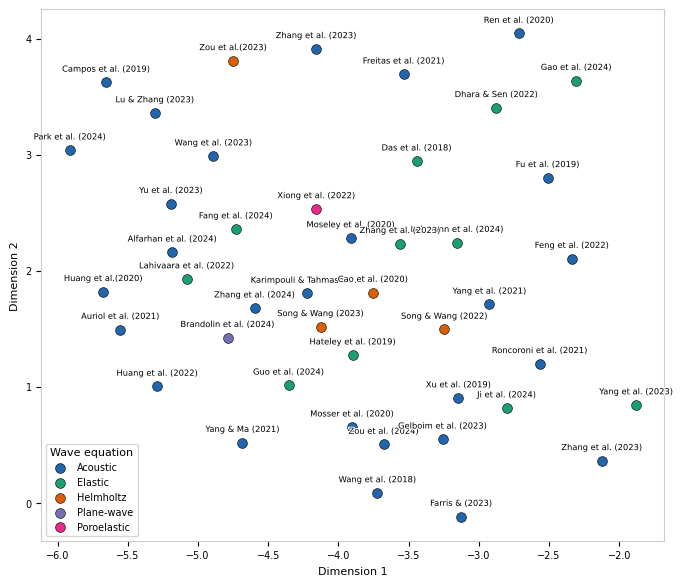

✓ Guardado: mapa_categorico.pdf y mapa_categorico.png


In [60]:
# ── 6. Color por tipo de ecuación ─────────────────────────────────────────────
eq_col = next((c for c in df.columns if "Ecuaci" in c), None)
 
def norm_eq(v):
    v = str(v).lower()
    if "elastic" in v and "helmholtz" in v: return "Elastic + Helmholtz"
    if "elastic" in v:   return "Elastic"
    if "helmholtz" in v: return "Helmholtz"
    if "poro" in v or "biot" in v: return "Poroelastic"
    if "plane" in v:     return "Plane-wave"
    return "Acoustic"
 
eq_labels = df[eq_col].apply(norm_eq).tolist() if eq_col else ["Unknown"] * len(df)
eq_types  = sorted(set(eq_labels))
palette   = ["#2166AC", "#1B9E75", "#D95F02", "#7570B3", "#E7298A", "#A6761D"]
color_map = {eq: palette[i % len(palette)] for i, eq in enumerate(eq_types)}
 
# ── 7. Plot ───────────────────────────────────────────────────────────────────
labels = [p.split(". ", 1)[1] if ". " in p else p for p in df["paper"].tolist()]
 
fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
 
for eq in eq_types:
    idx = [i for i, e in enumerate(eq_labels) if e == eq]
    ax.scatter(coords[idx, 0], coords[idx, 1], c=color_map[eq],
               s=50, zorder=3, label=eq, edgecolors="black", linewidths=0.4)
 
dy = (coords[:, 1].max() - coords[:, 1].min()) * 0.018
for i, label in enumerate(labels):
    short = label if len(label) < 26 else label[:23] + "…"
    txt = ax.text(coords[i, 0], coords[i, 1] + dy, short,
                  fontsize=6, color="black", ha="center", va="bottom", zorder=4)
    txt.set_path_effects([pe.Stroke(linewidth=1.5, foreground="white"), pe.Normal()])
 
legend = ax.legend(title="Wave equation", title_fontsize=8, fontsize=7,
                   frameon=True, facecolor="white", edgecolor="#cccccc", loc="best")
legend.get_title().set_color("black")
 
ax.set_xlabel("Dimension 1", fontsize=8)
ax.set_ylabel("Dimension 2", fontsize=8)
ax.tick_params(labelsize=7)
for spine in ax.spines.values():
    spine.set_edgecolor("#cccccc")
    spine.set_linewidth(0.8)
 
plt.tight_layout(pad=1.2)
plt.savefig("mapa_categorico.pdf", dpi=300, bbox_inches="tight", facecolor="white")
plt.savefig("mapa_categorico.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print("✓ Guardado: mapa_categorico.pdf y mapa_categorico.png")